Events: 2325

Parameters
----------

mu   = 0.3073403153821932
K    = 0.913597360159584
a    = 1.3283648314312395
beta = 1.748655122782874

Time-rescaled statistics
------------------------

Mean: 1.0004321015827269
Variance: 1.032095039983419


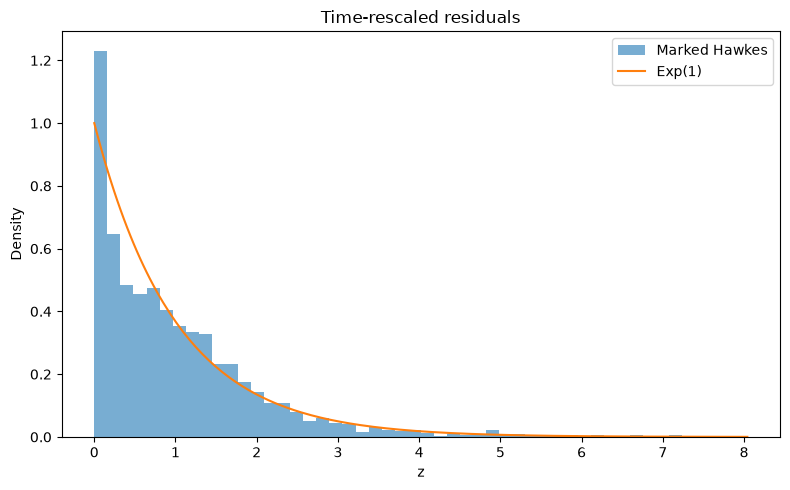


KS test
-------

Statistic: 0.057048604603819705
p-value: 5.137390351728343e-07


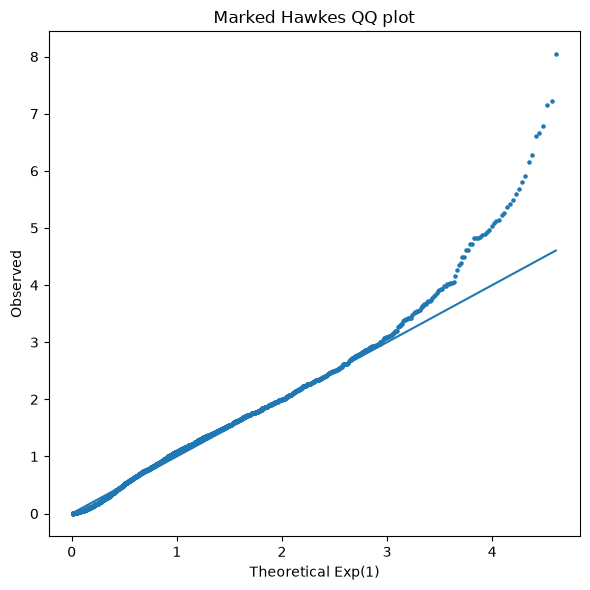


Conclusion:

For a correct marked Hawkes model:

- mean(z) should be close to 1
- variance(z) should be close to 1
- histogram should match Exp(1)
- QQ plot should be approximately linear
- KS test should not reject Exp(1)

Compare this with the previous simple Hawkes model.



In [1]:
# ==============================================================
# Notebook 7: Marked Hawkes Goodness-of-Fit
#
# Goal:
# - Validate the marked Hawkes model
# - Use time-rescaling theorem
#
# If the model is correct:
#
# z_i = integral(lambda(t))dt
#
# should follow:
#
# z_i ~ Exponential(1)
#
# ==============================================================


# --------------------------------------------------------------
# 1. Imports
# --------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import expon, kstest


# --------------------------------------------------------------
# 2. Load earthquake data
# --------------------------------------------------------------

df = pd.read_csv(
    "../data/earthquakes_greece_2016_2026.csv"
)

df["time"] = pd.to_datetime(df["time"])

df = (
    df
    .sort_values("time")
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 3. Prepare times and magnitudes
# --------------------------------------------------------------

t0 = df["time"].iloc[0]

times = (
    df["time"] - t0
).dt.total_seconds() / (24 * 3600)

times = times.values


magnitudes = df["mag"].values


T = times[-1]

M0 = 4.5


print("Events:", len(times))


# --------------------------------------------------------------
# 4. Load fitted marked Hawkes parameters
# --------------------------------------------------------------

mu, K, a, beta = np.load(
    "../data/marked_hawkes_params.npy"
)


print("""
Parameters
----------
""")

print("mu   =", mu)
print("K    =", K)
print("a    =", a)
print("beta =", beta)



# --------------------------------------------------------------
# 5. Time-rescaling transformation
#
# Compute:
#
# z_i = integral from t(i-1) to t(i) of lambda(t) dt
#
# For marked Hawkes:
#
# lambda(t)=
# mu +
# sum(K*exp(a(Mi-M0))*exp(-beta(t-ti)))
#
# --------------------------------------------------------------


z = []


for i in range(1, len(times)):

    t_previous = times[i-1]
    t_current = times[i]


    # background contribution

    integral = (
        mu *
        (t_current - t_previous)
    )


    # triggered contribution

    history_times = times[:i]
    history_mag = magnitudes[:i]


    integral += np.sum(
        (
            K
            *
            np.exp(
                a*(history_mag-M0)
            )
            /
            beta
        )
        *
        (
            np.exp(
                -beta*(t_previous-history_times)
            )
            -
            np.exp(
                -beta*(t_current-history_times)
            )
        )
    )


    z.append(integral)



z = np.array(z)



# --------------------------------------------------------------
# 6. Check transformed statistics
# --------------------------------------------------------------

print("""
Time-rescaled statistics
------------------------
""")

print("Mean:", z.mean())
print("Variance:", z.var())



# --------------------------------------------------------------
# 7. Histogram vs Exp(1)
# --------------------------------------------------------------

x = np.linspace(
    0,
    max(z),
    200
)


plt.figure(figsize=(8,5))


plt.hist(
    z,
    bins=50,
    density=True,
    alpha=0.6,
    label="Marked Hawkes"
)


plt.plot(
    x,
    expon.pdf(x),
    label="Exp(1)"
)


plt.xlabel("z")
plt.ylabel("Density")

plt.title(
    "Time-rescaled residuals"
)

plt.legend()

plt.tight_layout()

plt.show()



# --------------------------------------------------------------
# 8. Kolmogorov-Smirnov test
#
# H0:
# z comes from Exp(1)
#
# --------------------------------------------------------------

ks_stat, p_value = kstest(
    z,
    "expon"
)


print("""
KS test
-------
""")

print("Statistic:", ks_stat)
print("p-value:", p_value)



# --------------------------------------------------------------
# 9. QQ plot
# --------------------------------------------------------------

sorted_z = np.sort(z)


theoretical = expon.ppf(
    np.linspace(
        0.01,
        0.99,
        len(z)
    )
)


plt.figure(figsize=(6,6))


plt.scatter(
    theoretical,
    sorted_z,
    s=5
)


plt.plot(
    theoretical,
    theoretical
)


plt.xlabel(
    "Theoretical Exp(1)"
)

plt.ylabel(
    "Observed"
)

plt.title(
    "Marked Hawkes QQ plot"
)


plt.tight_layout()

plt.show()



# --------------------------------------------------------------
# 10. Conclusion
# --------------------------------------------------------------

print("""
Conclusion:

For a correct marked Hawkes model:

- mean(z) should be close to 1
- variance(z) should be close to 1
- histogram should match Exp(1)
- QQ plot should be approximately linear
- KS test should not reject Exp(1)

Compare this with the previous simple Hawkes model.
""")